# **Feed Forward Network con PyTorch**
* Oscar Ivanovich Avila Chiu 35676

En esta actividad crearás, entrenarás y evaluarás una red neuronal de arquitectura feed forward (o MLP) utilizando PyTorch y el conjunto de datos MNIST.

In [137]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import gzip
from pathlib import Path
import seaborn as sns

In [138]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [139]:
def load_mnist_dataset(mnist_path):
  x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
  y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

  x_train = x_trainval[:50000]
  y_train = y_trainval[:50000]

  x_val = x_trainval[50000:]
  y_val = y_trainval[50000:]

  x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
  y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

  return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
  with gzip.open(path, 'rb') as data:
    labels = data.read()[8:]
    return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
  with gzip.open(path, 'rb') as data:
    _ = int.from_bytes(data.read(4), 'big')
    num_images = int.from_bytes(data.read(4), 'big')
    rows = int.from_bytes(data.read(4), 'big')
    cols = int.from_bytes(data.read(4), 'big')
    images = data.read()
    return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [140]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('data')

In [141]:
class MNIST_Digits(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X.reshape(-1, 28*28), dtype=torch.float32).to(device)
    self.y = torch.tensor(y.squeeze(), dtype=torch.long).to(device)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [142]:
train_data = MNIST_Digits(x_train, y_train)
val_data = MNIST_Digits(x_val, y_val)
test_data = MNIST_Digits(x_test, y_test)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 50000
Validation data size: 10000
Test data size: 10000


## Defining the Neural Network

In [143]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, patience, delta):
  training_losses = []
  validation_losses = []

  val_loss_history = []

  for epoch in range(_num_epochs):
    _model.train()
    running_loss = 0.0
    for X_batch, y_batch in tqdm(_train_loader, desc=f"Epoch {epoch + 1}/{_num_epochs}"):
      _optimizer.zero_grad()
      outputs = _model(X_batch)
      loss = _criterion(outputs, y_batch)
      loss.backward()
      _optimizer.step()
      running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(_train_loader.dataset)
    training_losses.append(epoch_train_loss)

    _model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
      for X_val, y_val in _val_loader:
        val_outputs = _model(X_val)
        val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)

        preds = torch.argmax(val_outputs, dim=1)
        correct += (preds == y_val).sum().item()
        total += y_val.size(0)

    epoch_val_loss = val_loss / len(_val_loader.dataset)
    epoch_val_acc = correct / total
    validation_losses.append(epoch_val_loss)
    val_loss_history.append(epoch_val_loss)

    print(f"Epoch {epoch+1}: "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, "
          f"Val Accuracy: {epoch_val_acc:.4f}")
    print("")

    # Early stopping con delta
    if len(val_loss_history) > patience:
      loss_diff = abs(val_loss_history[-patience-1] - val_loss_history[-1])
      if loss_diff < delta and val_loss_history[-patience-1] >= val_loss_history[-1]:
        print(f"Early stopping triggered at epoch {epoch+1} (delta={delta}, patience={patience})")
        break

  return training_losses, validation_losses

# **Entrenamiento tres diferentes modelos**

In [144]:
# MODELO 1
model1 = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

# CAMBIOS ENTRE MODELOS
optimizer = optim.Adam(model1.parameters(), lr=0.1, weight_decay=1e-4)

num_epochs = 10
patience = 5
delta = 0.001
batch_size = 100

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model1,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    delta)

Epoch 1/10: 100%|██████████| 500/500 [00:06<00:00, 82.80it/s]


Epoch 1: Train Loss: 370.3183, Val Loss: 2.3120, Val Accuracy: 0.1064



Epoch 2/10: 100%|██████████| 500/500 [00:05<00:00, 91.47it/s]


Epoch 2: Train Loss: 2.3060, Val Loss: 2.3052, Val Accuracy: 0.1064



Epoch 3/10: 100%|██████████| 500/500 [00:07<00:00, 63.31it/s]


...

Epoch 8: Train Loss: 2.3083, Val Loss: 2.3082, Val Accuracy: 0.1064



Epoch 9/10: 100%|██████████| 500/500 [00:19<00:00, 26.08it/s]


Epoch 9: Train Loss: 199.7802, Val Loss: 2.3103, Val Accuracy: 0.0991



Epoch 10/10: 100%|██████████| 500/500 [00:18<00:00, 26.53it/s]


Epoch 10: Train Loss: 2.3074, Val Loss: 2.3141, Val Accuracy: 0.1064



In [145]:
# MODELO 2
model2 = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Dropout(0.2),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

# CAMBIOS ENTRE MODELOS
optimizer = optim.Adam(model2.parameters(), lr=0.01, weight_decay=1e-4)

num_epochs = 30
patience = 5
delta = 0.001
batch_size = 200

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model2,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    delta)

Epoch 1/30: 100%|██████████| 250/250 [00:04<00:00, 58.50it/s]


Epoch 1: Train Loss: 5.6034, Val Loss: 1.2595, Val Accuracy: 0.5606



Epoch 2/30: 100%|██████████| 250/250 [00:04<00:00, 50.08it/s]


Epoch 2: Train Loss: 1.0763, Val Loss: 0.8647, Val Accuracy: 0.6839



Epoch 3/30: 100%|██████████| 250/250 [00:04<00:00, 59.21it/s]


...

Epoch 28: Train Loss: 1.4030, Val Loss: 1.3096, Val Accuracy: 0.5159



Epoch 29/30: 100%|██████████| 250/250 [00:11<00:00, 21.34it/s]


Epoch 29: Train Loss: 1.4509, Val Loss: 1.3832, Val Accuracy: 0.5244



Epoch 30/30: 100%|██████████| 250/250 [00:11<00:00, 21.38it/s]


Epoch 30: Train Loss: 1.3076, Val Loss: 1.4456, Val Accuracy: 0.5550



In [146]:
# MODELO 3
model3 = nn.Sequential(
  nn.Linear(28*28, 512),
  nn.ReLU(),
  nn.Dropout(0.3),
  nn.Linear(512, 256),
  nn.ReLU(),
  nn.Dropout(0.2),
  nn.Linear(256, 10)
).to(device)

criterion = nn.CrossEntropyLoss()

# CAMBIOS ENTRE MODELOS
optimizer = optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 50
patience = 5
delta = 0.001
batch_size = 300

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

train_losses, val_losses = train(
    model3,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    delta)

Epoch 1/50: 100%|██████████| 167/167 [00:04<00:00, 37.29it/s]


Epoch 1: Train Loss: 0.8796, Val Loss: 0.1525, Val Accuracy: 0.9549



Epoch 2/50: 100%|██████████| 167/167 [00:04<00:00, 34.12it/s]


Epoch 2: Train Loss: 0.2175, Val Loss: 0.1173, Val Accuracy: 0.9649



Epoch 3/50: 100%|██████████| 167/167 [00:04<00:00, 34.45it/s]


...

Epoch 11: Train Loss: 0.0794, Val Loss: 0.1028, Val Accuracy: 0.9745



Epoch 12/50: 100%|██████████| 167/167 [00:05<00:00, 28.12it/s]


Epoch 12: Train Loss: 0.0821, Val Loss: 0.0891, Val Accuracy: 0.9753



Epoch 13/50: 100%|██████████| 167/167 [00:05<00:00, 29.36it/s]


Epoch 13: Train Loss: 0.0817, Val Loss: 0.0887, Val Accuracy: 0.9759

Early stopping triggered at epoch 13 (delta=0.001, patience=5)


#**Comparación entre modelos**

In [147]:
def evaluate_model(model, test_loader, criterion):
  model.eval()
  correct = 0
  test_loss = 0.0
  with torch.no_grad():
    for X_batch, y_batch in test_loader:
      outputs = model(X_batch)
      loss = criterion(outputs, y_batch)
      test_loss += loss.item() * X_batch.size(0)
      preds = torch.argmax(outputs, dim=1)
      correct += (preds == y_batch).sum().item()

  test_loss /= len(test_loader.dataset)
  test_acc = correct / len(test_loader.dataset)
  return test_loss, test_acc

# Evaluación de los 3 modelos
test_loss1, test_acc1 = evaluate_model(model1, test_loader, criterion)
test_loss2, test_acc2 = evaluate_model(model2, test_loader, criterion)
test_loss3, test_acc3 = evaluate_model(model3, test_loader, criterion)

print(f"Modelo 1 - Test Loss: {test_loss1:.4f}, Test Accuracy: {test_acc1:.4f}")
print(f"Modelo 2 - Test Loss: {test_loss2:.4f}, Test Accuracy: {test_acc2:.4f}")
print(f"Modelo 3 - Test Loss: {test_loss3:.4f}, Test Accuracy: {test_acc3:.4f}")

# Segun mayor accuracy
best_model = model1
best_acc = test_acc1

if test_acc2 > best_acc:
    best_model = model2
    best_acc = test_acc2
if test_acc3 > best_acc:
    best_model = model3
    best_acc = test_acc3

print(f"\nMejor modelo:\n{best_model} \nDebido a Mejor Accuracy = {best_acc:.4f}")

Modelo 1 - Test Loss: 2.3123, Test Accuracy: 0.1135
Modelo 2 - Test Loss: 1.3944, Test Accuracy: 0.5433
Modelo 3 - Test Loss: 0.0856, Test Accuracy: 0.9759

Mejor modelo:
Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=256, out_features=10, bias=True)
) 
Debido a Mejor Accuracy = 0.9759


## **Evaluación del mejor modelo**

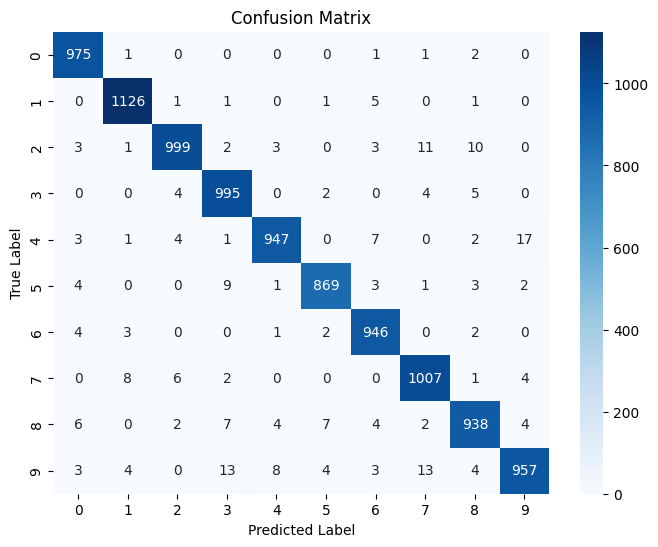

In [148]:
# Evaluación final con best_model
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for X_batch, y_batch in test_loader:
    outputs = best_model(X_batch)
    preds = torch.argmax(outputs, dim=1)
    all_preds.append(preds.cpu().numpy())
    all_labels.append(y_batch.cpu().numpy())

# Convertir listas a arrays
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Matriz de confusión
conf_matrix = np.zeros((10, 10), dtype=int)
for true_label, pred_label in zip(y_true, y_pred):
  conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [149]:
# Cálculo de métricas por clase
precision = np.zeros(10)
recall = np.zeros(10)
f1_score = np.zeros(10)

# Se van agregando segun la etiqueta
for i in range(10):
  tp = conf_matrix[i, i]
  fp = conf_matrix[:, i].sum() - tp
  fn = conf_matrix[i, :].sum() - tp
  precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0
  recall[i] = tp / (tp + fn) if (tp + fn) > 0 else 0
  f1_score[i] = (2 * precision[i] * recall[i]) / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0

# Accuracy global
accuracy_global = np.trace(conf_matrix) / np.sum(conf_matrix)

# Mostrar resultados
print(f"Global Accuracy: {accuracy_global:.4f}\n")
for i in range(10):
  print(f"Class {i}: Precision = {precision[i]:.4f}, Recall = {recall[i]:.4f}, F1-score = {f1_score[i]:.4f}")

Global Accuracy: 0.9759

Class 0: Precision = 0.9770, Recall = 0.9949, F1-score = 0.9858
Class 1: Precision = 0.9843, Recall = 0.9921, F1-score = 0.9882
Class 2: Precision = 0.9833, Recall = 0.9680, F1-score = 0.9756
Class 3: Precision = 0.9660, Recall = 0.9851, F1-score = 0.9755
Class 4: Precision = 0.9824, Recall = 0.9644, F1-score = 0.9733
Class 5: Precision = 0.9819, Recall = 0.9742, F1-score = 0.9781
Class 6: Precision = 0.9733, Recall = 0.9875, F1-score = 0.9803
Class 7: Precision = 0.9692, Recall = 0.9796, F1-score = 0.9744
Class 8: Precision = 0.9690, Recall = 0.9630, F1-score = 0.9660
Class 9: Precision = 0.9726, Recall = 0.9485, F1-score = 0.9604


# **Reflexión personal**

Esta actividad me hizo darme cuenta de que, cuando no se usa GridSearchCV, uno debe probar todas las combinaciones posibles para encontrar el resultado que nos otorgue mayor accuracy y menores errores en validación. Con PyTorch noté que facilita muchos aspectos, como la implementación de ReLU, redes neuronales y funciones propias de la librería.

Sin duda, experimentar con métricas, capas ocultas y parámetros relacionados me recordó que el verdadero modelo se construye probando y ajustando hasta llegar a un punto satisfactorio. Además, medidas como early stopping ayudaron a que no se ejecutaran todas las épocas, ahorrando tiempo y recursos computacionales. Considero que al entrenar un modelo de ML, el tiempo es un factor valioso para tener más probabilidades de encontrar un mejor modelo.